## Method Pipeline generated by Claude on the Paper 

Remote Photoplethysmography Heart Rate Variability Detection Using Signal to Noise Ratio Bandpass Filtering

This method is using the CWT (Continous Wavelet Transform)

Generating synthetic rPPG signal...
Starting CWT-SNR rPPG Processing Pipeline...
Step 1: Interpolating signal...
Step 2: Forward CWT transformation...
Step 3: Finding maximum frequency...
F_max = 0.8125 Hz
Step 4: Calculating threshold...
Threshold D = 0.9846
Step 5-6: Finding optimal percentage using SNR...
Optimal percentage = 9.00%
Step 7: Adaptive frequency filtering...
Frequency range: [0.7394, 0.8856] Hz
Step 8: Signal reconstruction...
Step 9: Peak detection...
Detected 22 peaks
Step 10: HRV analysis...
Heart Rate: 43.2 BPM
RMSSD: 418.85 ms


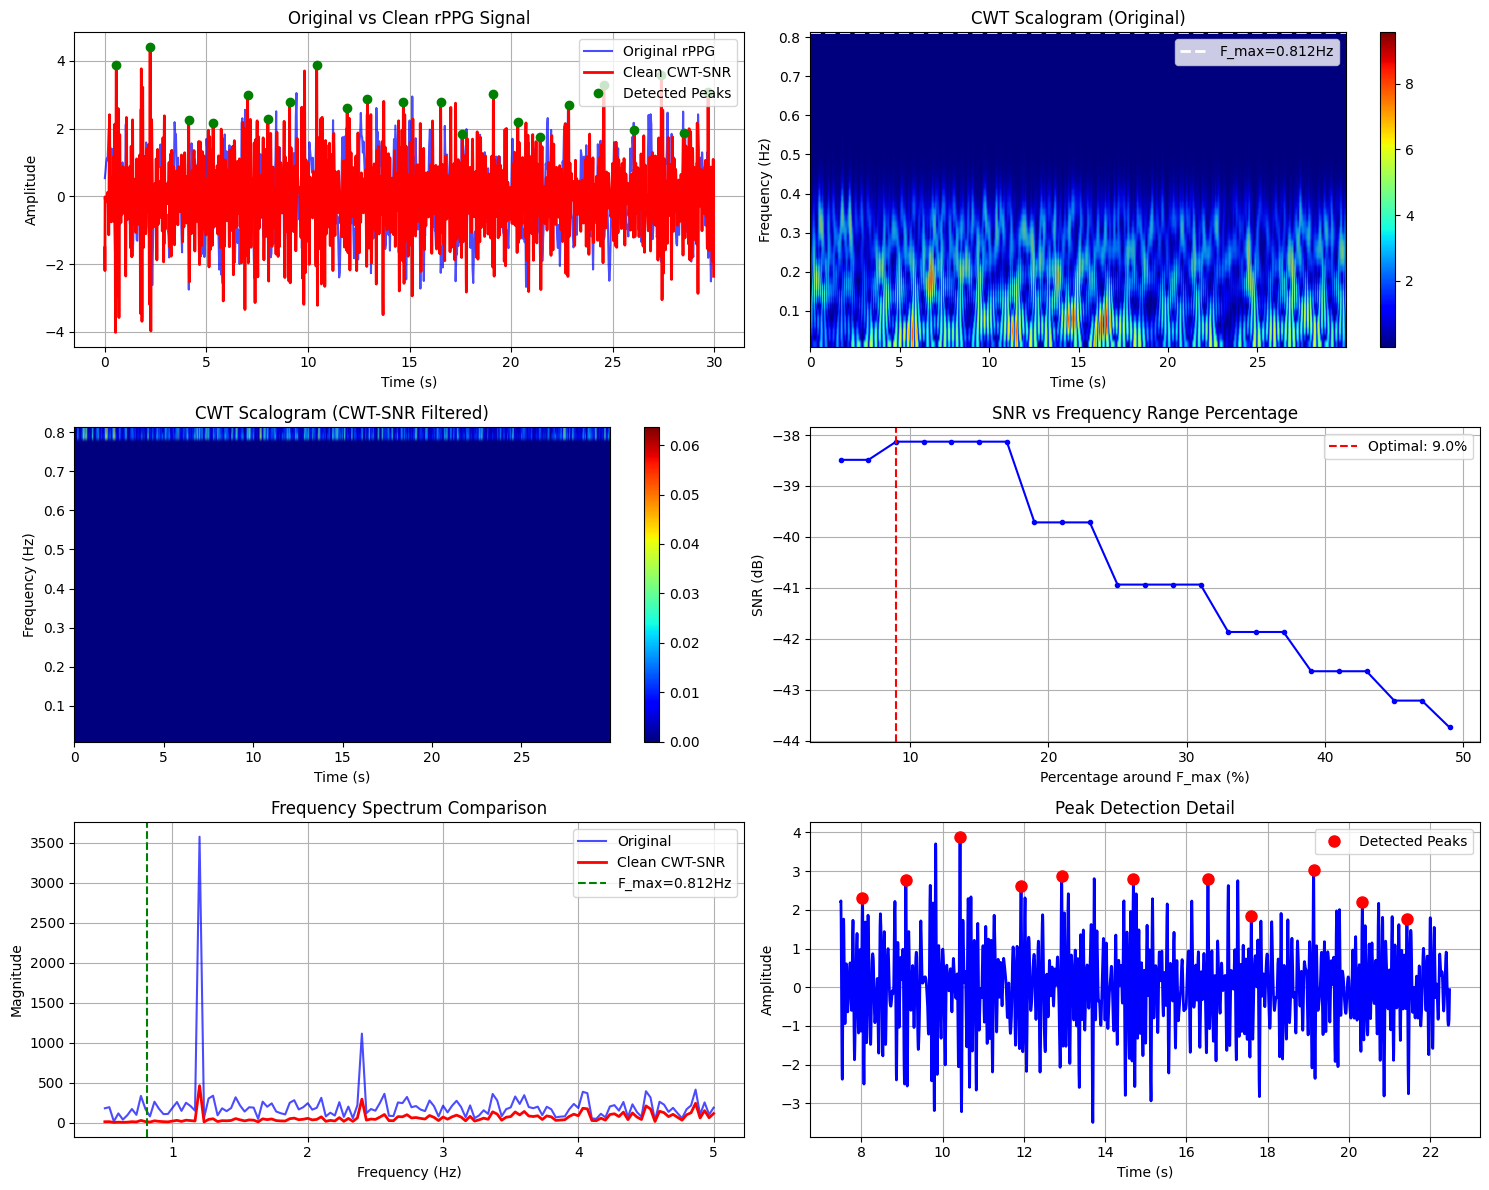


CWT-SNR PROCESSING RESULTS
Maximum frequency (F_max): 0.8125 Hz
Optimal percentage: 9.00%
Selected frequency range: [0.7394, 0.8856] Hz
Number of detected peaks: 22
Heart rate: 43.2 BPM
RMSSD: 418.85 ms
Mean RR interval: 1.389 s
RR interval std: 287.18 ms


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.interpolate import interp1d
import pywt
from scipy.signal import find_peaks
import warnings
warnings.filterwarnings('ignore')

class CWT_SNR_Processor:
    def __init__(self, original_fs=30, target_fs=240, wavelet='morl'):
        """
        Initialize CWT-SNR processor for rPPG signals
        
        Parameters:
        - original_fs: Original sampling frequency (Hz)
        - target_fs: Target sampling frequency after interpolation (Hz)
        - wavelet: Wavelet type for CWT ('morl' is more stable than 'cmor')
        """
        self.original_fs = original_fs
        self.target_fs = target_fs
        self.wavelet = wavelet
        self.hr_range = [0.75, 4.0]  # Heart rate frequency range (Hz)
        self.r = 0.8  # Threshold parameter from Equation 13
        
    def interpolate_signal(self, rppg_signal):
        """
        Step 1: Interpolate signal from 30Hz to 240Hz for smoothing
        """
        original_time = np.arange(len(rppg_signal)) / self.original_fs
        target_length = int(len(rppg_signal) * self.target_fs / self.original_fs)
        target_time = np.linspace(0, original_time[-1], target_length)
        
        interpolator = interp1d(original_time, rppg_signal, kind='cubic')
        interpolated_signal = interpolator(target_time)
        
        return interpolated_signal, target_time
    
    def forward_cwt(self, signal):
        """
        Step 2: Forward CWT Transformation (Equation 9)
        """
        # Generate scales more carefully to avoid too small values
        # Focus on heart rate relevant frequencies: 0.5 to 5 Hz
        frequencies = np.linspace(0.5, 5, 100)  # More focused frequency range
        
        # Calculate scales properly
        scales = pywt.frequency2scale(self.wavelet, frequencies)
        
        # Filter out scales that are too small (< 1)
        valid_scales_mask = scales >= 1.0
        scales = scales[valid_scales_mask]
        frequencies = frequencies[valid_scales_mask]
        
        # Ensure we have enough scales
        if len(scales) < 10:
            # Fallback to manual scale generation
            scales = np.logspace(0, 2, 50)  # From 1 to 100
            frequencies = pywt.scale2frequency(self.wavelet, scales) * self.target_fs
        
        # Perform CWT
        coefficients, frequencies_actual = pywt.cwt(signal, scales, self.wavelet)
        
        return coefficients, frequencies_actual, scales
    
    def find_max_frequency(self, coefficients, frequencies):
        """
        Step 3: Find Maximum Frequency (CWT-MAX)
        """
        # Filter frequencies within heart rate range
        hr_mask = (frequencies >= self.hr_range[0]) & (frequencies <= self.hr_range[1])
        
        # Ensure we have valid frequencies in the heart rate range
        if not np.any(hr_mask):
            # Fallback: extend range slightly if no frequencies found
            hr_mask = (frequencies >= 0.5) & (frequencies <= 4.5)
        
        hr_coefficients = coefficients[hr_mask]
        hr_frequencies = frequencies[hr_mask]
        
        if len(hr_frequencies) == 0:
            # Emergency fallback
            hr_coefficients = coefficients
            hr_frequencies = frequencies
            hr_mask = np.ones(len(frequencies), dtype=bool)
        
        # Find frequency with maximum accumulated magnitude
        magnitude_sum = np.sum(np.abs(hr_coefficients), axis=1)
        max_idx = np.argmax(magnitude_sum)
        f_max = hr_frequencies[max_idx]
        
        return f_max, max_idx, hr_mask
    
    def calculate_threshold(self, f_max):
        """
        Step 4: Calculate Threshold Parameter (Equation 13)
        D = r / F_max where r = 0.8
        """
        D = self.r / f_max
        return D
    
    def calculate_snr_periodogram(self, signal, percentage_range=np.arange(0.05, 0.5, 0.01)):
        """
        Step 5: SNR-Based Frequency Selection using Periodogram (Equation 12)
        """
        # Kaiser window with β = 38
        window = signal.windows.kaiser(len(signal), beta=38)
        
        # Calculate periodogram
        freqs, psd = signal.periodogram(signal, fs=self.target_fs, window=window)
        
        # Exclude fundamental and first 6 harmonics (as mentioned in paper)
        # This is a simplified implementation
        valid_freq_mask = freqs > 0.1  # Simple approach to exclude low frequencies
        
        return freqs[valid_freq_mask], psd[valid_freq_mask]
    
    def find_optimal_percentage(self, coefficients, frequencies, f_max, hr_mask):
        """
        Step 6: Find optimal percentage using SNR analysis
        """
        percentage_range = np.arange(0.05, 0.5, 0.02)  # 5% to 50%
        snr_values = []
        
        for p in percentage_range:
            # Define frequency range around f_max
            f_min = f_max * (1 - p)
            f_max_range = f_max * (1 + p)
            
            # Create mask for this frequency range
            freq_mask = (frequencies >= f_min) & (frequencies <= f_max_range)
            
            if np.sum(freq_mask) == 0:
                snr_values.append(0)
                continue
            
            # Calculate signal power in this range
            signal_power = np.mean(np.abs(coefficients[freq_mask])**2)
            
            # Calculate noise power (outside this range but within HR range)
            noise_mask = hr_mask & ~freq_mask
            if np.sum(noise_mask) > 0:
                noise_power = np.mean(np.abs(coefficients[noise_mask])**2)
                snr = signal_power / (noise_power + 1e-10)  # Avoid division by zero
            else:
                snr = signal_power
                
            snr_values.append(snr)
        
        # Find optimal percentage (maximum SNR)
        optimal_idx = np.argmax(snr_values)
        p_optimal = percentage_range[optimal_idx]
        
        return p_optimal, percentage_range, snr_values
    
    def adaptive_frequency_filtering(self, coefficients, frequencies, f_max, p_optimal):
        """
        Step 7: Adaptive Frequency Filtering
        """
        # Define optimal frequency range
        f_min = f_max * (1 - p_optimal)
        f_max_range = f_max * (1 + p_optimal)
        
        # Create filtered coefficients
        filtered_coefficients = np.zeros_like(coefficients)
        freq_mask = (frequencies >= f_min) & (frequencies <= f_max_range)
        filtered_coefficients[freq_mask] = coefficients[freq_mask]
        
        return filtered_coefficients, f_min, f_max_range
    
    def inverse_cwt(self, filtered_coefficients, scales):
        """
        Step 8: Signal Reconstruction using Inverse CWT (Equation 10)
        """
        # Simplified inverse CWT (PyWavelets doesn't have direct inverse)
        # This is an approximation using the reconstruction property
        reconstructed = np.real(np.sum(filtered_coefficients, axis=0))
        
        # Normalize
        reconstructed = (reconstructed - np.mean(reconstructed)) / np.std(reconstructed)
        
        return reconstructed
    
    def peak_detection(self, clean_signal, f_max):
        """
        Step 9: Peak Detection with threshold D = 0.8/F_max
        """
        D = self.calculate_threshold(f_max)
        min_distance = int(D * self.target_fs)  # Convert to samples
        
        # Find peaks
        peaks, properties = find_peaks(clean_signal, distance=min_distance)
        
        return peaks, properties
    
    def calculate_hrv_metrics(self, peaks, time_vector):
        """
        Step 10: Basic HRV Analysis
        """
        if len(peaks) < 2:
            return None
            
        # Calculate R-R intervals
        rr_intervals = np.diff(peaks) / self.target_fs  # Convert to seconds
        
        # Basic HRV metrics
        hrv_metrics = {
            'mean_rr': np.mean(rr_intervals),
            'std_rr': np.std(rr_intervals),
            'rmssd': np.sqrt(np.mean(np.diff(rr_intervals)**2)),
            'heart_rate_bpm': 60 / np.mean(rr_intervals) if len(rr_intervals) > 0 else 0
        }
        
        return hrv_metrics, rr_intervals
    
    def process_rppg_signal(self, rppg_signal, plot_results=True):
        """
        Complete CWT-SNR Pipeline
        """
        print("Starting CWT-SNR rPPG Processing Pipeline...")
        
        # Step 1: Interpolate signal
        print("Step 1: Interpolating signal...")
        interpolated_signal, time_vector = self.interpolate_signal(rppg_signal)
        
        # Step 2: Forward CWT
        print("Step 2: Forward CWT transformation...")
        coefficients, frequencies, scales = self.forward_cwt(interpolated_signal)
        
        # Step 3: Find maximum frequency
        print("Step 3: Finding maximum frequency...")
        f_max, max_idx, hr_mask = self.find_max_frequency(coefficients, frequencies)
        print(f"F_max = {f_max:.4f} Hz")
        
        # Step 4: Calculate threshold
        print("Step 4: Calculating threshold...")
        D = self.calculate_threshold(f_max)
        print(f"Threshold D = {D:.4f}")
        
        # Step 5-6: Find optimal percentage
        print("Step 5-6: Finding optimal percentage using SNR...")
        p_optimal, percentage_range, snr_values = self.find_optimal_percentage(
            coefficients, frequencies, f_max, hr_mask)
        print(f"Optimal percentage = {p_optimal:.2%}")
        
        # Step 7: Adaptive filtering
        print("Step 7: Adaptive frequency filtering...")
        filtered_coefficients, f_min, f_max_range = self.adaptive_frequency_filtering(
            coefficients, frequencies, f_max, p_optimal)
        print(f"Frequency range: [{f_min:.4f}, {f_max_range:.4f}] Hz")
        
        # Step 8: Inverse CWT
        print("Step 8: Signal reconstruction...")
        clean_signal = self.inverse_cwt(filtered_coefficients, scales)
        
        # Step 9: Peak detection
        print("Step 9: Peak detection...")
        peaks, properties = self.peak_detection(clean_signal, f_max)
        print(f"Detected {len(peaks)} peaks")
        
        # Step 10: HRV analysis
        print("Step 10: HRV analysis...")
        hrv_results = self.calculate_hrv_metrics(peaks, time_vector)
        
        if hrv_results:
            hrv_metrics, rr_intervals = hrv_results
            print(f"Heart Rate: {hrv_metrics['heart_rate_bpm']:.1f} BPM")
            print(f"RMSSD: {hrv_metrics['rmssd']*1000:.2f} ms")
        
        # Plotting results
        if plot_results:
            self.plot_results(rppg_signal, interpolated_signal, clean_signal, 
                            coefficients, filtered_coefficients, frequencies, 
                            time_vector, peaks, percentage_range, snr_values,
                            f_max, p_optimal)
        
        results = {
            'clean_signal': clean_signal,
            'original_signal': rppg_signal,
            'interpolated_signal': interpolated_signal,
            'time_vector': time_vector,
            'peaks': peaks,
            'f_max': f_max,
            'p_optimal': p_optimal,
            'frequency_range': [f_min, f_max_range],
            'hrv_metrics': hrv_metrics if hrv_results else None,
            'coefficients': coefficients,
            'filtered_coefficients': filtered_coefficients,
            'frequencies': frequencies
        }
        
        return results
    
    def plot_results(self, original, interpolated, clean, coefficients, 
                    filtered_coefficients, frequencies, time_vector, peaks,
                    percentage_range, snr_values, f_max, p_optimal):
        """
        Plot comprehensive results
        """
        fig, axes = plt.subplots(3, 2, figsize=(15, 12))
        
        # Plot 1: Original vs Clean Signal
        axes[0,0].plot(np.arange(len(original))/self.original_fs, original, 'b-', alpha=0.7, label='Original rPPG')
        axes[0,0].plot(time_vector, clean, 'r-', linewidth=2, label='Clean CWT-SNR')
        if len(peaks) > 0:
            axes[0,0].plot(time_vector[peaks], clean[peaks], 'go', markersize=6, label='Detected Peaks')
        axes[0,0].set_xlabel('Time (s)')
        axes[0,0].set_ylabel('Amplitude')
        axes[0,0].set_title('Original vs Clean rPPG Signal')
        axes[0,0].legend()
        axes[0,0].grid(True)
        
        # Plot 2: CWT Scalogram (Original)
        im1 = axes[0,1].imshow(np.abs(coefficients), aspect='auto', cmap='jet', 
                              extent=[time_vector[0], time_vector[-1], frequencies[-1], frequencies[0]])
        axes[0,1].set_ylabel('Frequency (Hz)')
        axes[0,1].set_xlabel('Time (s)')
        axes[0,1].set_title('CWT Scalogram (Original)')
        axes[0,1].axhline(y=f_max, color='white', linestyle='--', linewidth=2, label=f'F_max={f_max:.3f}Hz')
        axes[0,1].legend()
        plt.colorbar(im1, ax=axes[0,1])
        
        # Plot 3: CWT Scalogram (Filtered)
        im2 = axes[1,0].imshow(np.abs(filtered_coefficients), aspect='auto', cmap='jet',
                              extent=[time_vector[0], time_vector[-1], frequencies[-1], frequencies[0]])
        axes[1,0].set_ylabel('Frequency (Hz)')
        axes[1,0].set_xlabel('Time (s)')
        axes[1,0].set_title('CWT Scalogram (CWT-SNR Filtered)')
        plt.colorbar(im2, ax=axes[1,0])
        
        # Plot 4: SNR vs Percentage
        axes[1,1].plot(percentage_range*100, 10*np.log10(np.array(snr_values) + 1e-10), 'b.-')
        axes[1,1].axvline(x=p_optimal*100, color='red', linestyle='--', 
                         label=f'Optimal: {p_optimal:.1%}')
        axes[1,1].set_xlabel('Percentage around F_max (%)')
        axes[1,1].set_ylabel('SNR (dB)')
        axes[1,1].set_title('SNR vs Frequency Range Percentage')
        axes[1,1].legend()
        axes[1,1].grid(True)
        
        # Plot 5: Frequency Spectrum
        fft_orig = np.fft.fft(interpolated)
        fft_clean = np.fft.fft(clean)
        freqs_fft = np.fft.fftfreq(len(interpolated), 1/self.target_fs)
        
        positive_freqs = freqs_fft[:len(freqs_fft)//2]
        hr_freq_mask = (positive_freqs >= 0.5) & (positive_freqs <= 5)
        
        axes[2,0].plot(positive_freqs[hr_freq_mask], np.abs(fft_orig[:len(freqs_fft)//2][hr_freq_mask]), 
                      'b-', alpha=0.7, label='Original')
        axes[2,0].plot(positive_freqs[hr_freq_mask], np.abs(fft_clean[:len(freqs_fft)//2][hr_freq_mask]), 
                      'r-', linewidth=2, label='Clean CWT-SNR')
        axes[2,0].axvline(x=f_max, color='green', linestyle='--', label=f'F_max={f_max:.3f}Hz')
        axes[2,0].set_xlabel('Frequency (Hz)')
        axes[2,0].set_ylabel('Magnitude')
        axes[2,0].set_title('Frequency Spectrum Comparison')
        axes[2,0].legend()
        axes[2,0].grid(True)
        
        # Plot 6: Peak Detection Detail
        if len(peaks) > 10:
            start_idx = len(clean)//4
            end_idx = start_idx + len(clean)//2
            detail_time = time_vector[start_idx:end_idx]
            detail_signal = clean[start_idx:end_idx]
            detail_peaks = peaks[(peaks >= start_idx) & (peaks < end_idx)] - start_idx
            
            axes[2,1].plot(detail_time, detail_signal, 'b-', linewidth=2)
            if len(detail_peaks) > 0:
                axes[2,1].plot(detail_time[detail_peaks], detail_signal[detail_peaks], 
                              'ro', markersize=8, label='Detected Peaks')
            axes[2,1].set_xlabel('Time (s)')
            axes[2,1].set_ylabel('Amplitude')
            axes[2,1].set_title('Peak Detection Detail')
            axes[2,1].legend()
            axes[2,1].grid(True)
        else:
            axes[2,1].text(0.5, 0.5, 'Insufficient peaks\nfor detail view', 
                          ha='center', va='center', transform=axes[2,1].transAxes)
            axes[2,1].set_title('Peak Detection Detail')
        
        plt.tight_layout()
        plt.show()

# Example usage and testing
def generate_synthetic_rppg(duration=60, fs=30, hr_bpm=75, noise_level=0.5):
    """
    Generate synthetic rPPG signal for testing
    """
    t = np.arange(0, duration, 1/fs)
    
    # Base heart rate signal
    hr_freq = hr_bpm / 60  # Convert BPM to Hz
    heart_signal = np.sin(2 * np.pi * hr_freq * t)
    
    # Add some HRV (heart rate variability)
    hrv_modulation = 0.1 * np.sin(2 * np.pi * 0.1 * t)  # 0.1 Hz modulation
    heart_signal *= (1 + hrv_modulation)
    
    # Add harmonics
    heart_signal += 0.3 * np.sin(2 * np.pi * 2 * hr_freq * t)  # 2nd harmonic
    heart_signal += 0.1 * np.sin(2 * np.pi * 3 * hr_freq * t)  # 3rd harmonic
    
    # Add noise and artifacts
    noise = noise_level * np.random.randn(len(t))
    motion_artifact = 0.8 * np.sin(2 * np.pi * 0.3 * t) * np.random.randn(len(t)) * 0.1
    
    # Combine all components
    rppg_signal = heart_signal + noise + motion_artifact
    
    return rppg_signal, t

# Example usage
if __name__ == "__main__":
    # Generate synthetic rPPG signal
    print("Generating synthetic rPPG signal...")
    synthetic_rppg, original_time = generate_synthetic_rppg(duration=30, hr_bpm=72, noise_level=0.8)
    
    # Initialize processor
    processor = CWT_SNR_Processor()
    
    # Process the signal
    results = processor.process_rppg_signal(synthetic_rppg, plot_results=True)
    
    # Display results
    print("\n" + "="*50)
    print("CWT-SNR PROCESSING RESULTS")
    print("="*50)
    print(f"Maximum frequency (F_max): {results['f_max']:.4f} Hz")
    print(f"Optimal percentage: {results['p_optimal']:.2%}")
    print(f"Selected frequency range: [{results['frequency_range'][0]:.4f}, {results['frequency_range'][1]:.4f}] Hz")
    print(f"Number of detected peaks: {len(results['peaks'])}")
    
    if results['hrv_metrics']:
        print(f"Heart rate: {results['hrv_metrics']['heart_rate_bpm']:.1f} BPM")
        print(f"RMSSD: {results['hrv_metrics']['rmssd']*1000:.2f} ms")
        print(f"Mean RR interval: {results['hrv_metrics']['mean_rr']:.3f} s")
        print(f"RR interval std: {results['hrv_metrics']['std_rr']*1000:.2f} ms")